# Data Preparation

In [2]:
# Data Preparation for COVID-19 Image Analysis
# This notebook prepares the dataset for training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set up paths
DATA_DIR = Path('data')
TRAIN_CSV = DATA_DIR / 'train.csv'
META_TRAIN_CSV = DATA_DIR / 'meta_train.csv'
META_TEST_CSV = DATA_DIR / 'meta_test.csv'
TRAIN_IMAGES_DIR = DATA_DIR / '256px' / 'train' / 'train'
TEST_IMAGES_DIR = DATA_DIR / '256px' / 'test' / 'test'

print("Data directories:")
print(f"Train images: {TRAIN_IMAGES_DIR}")
print(f"Test images: {TEST_IMAGES_DIR}")
print(f"Train CSV: {TRAIN_CSV.exists()}")
print(f"Meta train CSV: {META_TRAIN_CSV.exists()}")
print(f"Meta test CSV: {META_TEST_CSV.exists()}")

Data directories:
Train images: data/256px/train/train
Test images: data/256px/test/test
Train CSV: True
Meta train CSV: True
Meta test CSV: True


In [3]:
# Load the training data
print("Loading training data...")
train_df = pd.read_csv(TRAIN_CSV)
meta_train_df = pd.read_csv(META_TRAIN_CSV)
meta_test_df = pd.read_csv(META_TEST_CSV)

print(f"\nTrain CSV shape: {train_df.shape}")
print(f"Meta train CSV shape: {meta_train_df.shape}")
print(f"Meta test CSV shape: {meta_test_df.shape}")

print("\nFirst few rows of train.csv:")
print(train_df.head())


Loading training data...

Train CSV shape: (6334, 8)
Meta train CSV shape: (6334, 3)
Meta test CSV shape: (1263, 3)

First few rows of train.csv:
  ImageInstanceUID StudyInstanceUID                label_id  study_label  \
0     000a312787f2     5776db0cec75      Typical Appearance            1   
1     000c3a3f293f     ff0879eb20ed  Negative for Pneumonia            0   
2     0012ff7358bc     9d514ce429a7      Typical Appearance            1   
3     001398f4ff4f     28dddc8559b2     Atypical Appearance            3   
4     001bd15d1891     dfd9fdd85a3e      Typical Appearance            1   

   height  width                                              boxes  \
0    3488   4256  [{'x': 789.28836, 'y': 582.43035, 'width': 102...   
1    2320   2832        [{'x': 0, 'y': 0, 'width': 1, 'height': 1}]   
2    2544   3056  [{'x': 677.42216, 'y': 197.97662, 'width': 867...   
3    3520   4280  [{'x': 2729, 'y': 2181.33331, 'width': 948.000...   
4    2800   3408  [{'x': 623.23328, 'y': 1

In [4]:
# Explore the data structure
print("Dataset Information:")
print(f"\nColumns in train.csv: {train_df.columns.tolist()}")
print(f"\nUnique labels: {train_df['label_id'].unique()}")
print(f"\nLabel distribution:")
print(train_df['label_id'].value_counts())
print(f"\nStudy label distribution:")
print(train_df['study_label'].value_counts().sort_index())


Dataset Information:

Columns in train.csv: ['ImageInstanceUID', 'StudyInstanceUID', 'label_id', 'study_label', 'height', 'width', 'boxes', 'image_label']

Unique labels: ['Typical Appearance' 'Negative for Pneumonia' 'Atypical Appearance'
 'Indeterminate Appearance']

Label distribution:
label_id
Typical Appearance          3007
Negative for Pneumonia      1736
Indeterminate Appearance    1108
Atypical Appearance          483
Name: count, dtype: int64

Study label distribution:
study_label
0    1736
1    3007
2    1108
3     483
Name: count, dtype: int64


In [5]:
# IMPORTANT: Image files are named with pattern: {StudyInstanceUID}_{something}_{ImageInstanceUID}.jpg
# So we need to search for files ending with _{ImageInstanceUID}.jpg
# This cell provides the optimized function to find image paths

from glob import glob
from pathlib import Path

# Build lookup dictionaries once
def build_image_lookup_dict(is_train=True):
    """Build a dictionary mapping ImageInstanceUID to full file path"""
    if is_train:
        search_dir = TRAIN_IMAGES_DIR
    else:
        search_dir = TEST_IMAGES_DIR
    
    lookup_dict = {}
    # Scan directory once and extract ImageInstanceUID from each filename
    for file_path in Path(search_dir).glob("*.jpg"):
        filename = file_path.name
        # Extract ImageInstanceUID from filename (last part before .jpg)
        # Pattern: {StudyInstanceUID}_{something}_{ImageInstanceUID}.jpg
        parts = filename.rsplit('_', 1)  # Split from right, get last part
        if len(parts) == 2:
            image_id = parts[1].replace('.jpg', '')
            lookup_dict[image_id] = str(file_path)
    
    return lookup_dict

def get_image_path(image_id, lookup_dict):
    """Find the image file path using pre-built lookup dictionary"""
    return lookup_dict.get(image_id, None)

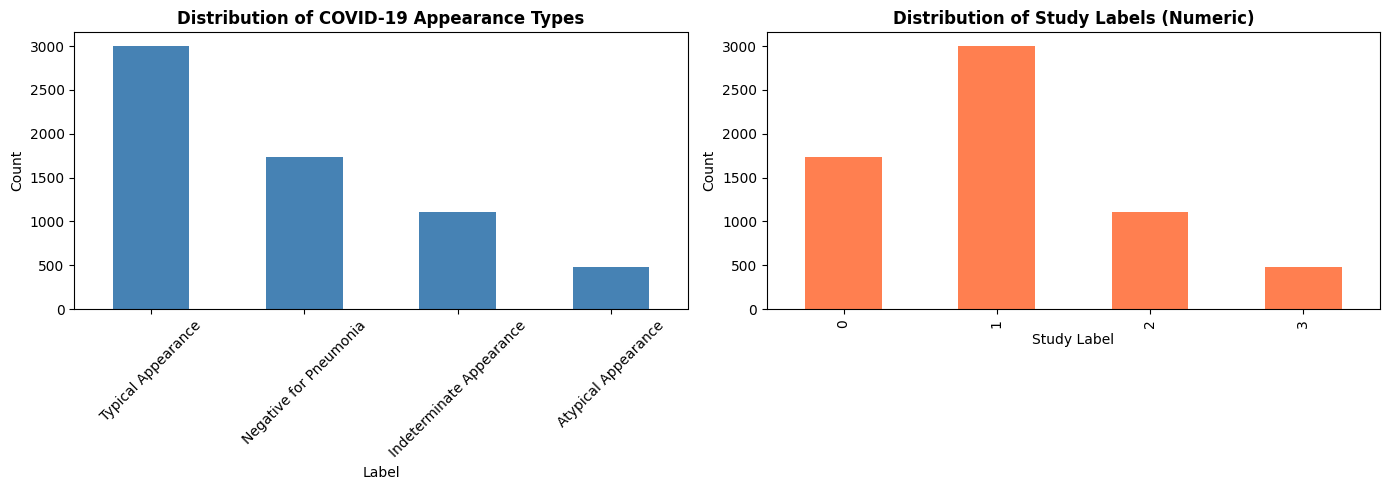


Class Distribution Statistics:
label_id
Typical Appearance          3007
Negative for Pneumonia      1736
Indeterminate Appearance    1108
Atypical Appearance          483
Name: count, dtype: int64

Total images: 6334
Images with bounding boxes: 6334


In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
train_df['label_id'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of COVID-19 Appearance Types', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Label', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Study label distribution
train_df['study_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution of Study Labels (Numeric)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Study Label', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("\nClass Distribution Statistics:")
print(train_df['label_id'].value_counts())
print(f"\nTotal images: {len(train_df)}")
print(f"Images with bounding boxes: {train_df[train_df['boxes'].str.contains('width', na=False)].shape[0]}")


In [7]:
# Check if image files exist and create file paths
# Using optimized lookup dictionary approach

# Build lookup dictionary once
print("Building image path lookup dictionary...")
image_lookup = build_image_lookup_dict(is_train=True)
print(f"Found {len(image_lookup)} image files in directory")

# Add image paths to dataframe using dictionary lookup (O(1) instead of O(n))
print("Mapping image paths to dataframe...")
train_df['image_path'] = train_df['ImageInstanceUID'].map(image_lookup)

# Check how many images actually exist (path will be None if not found)
train_df['image_exists'] = train_df['image_path'].notna()

# Print debug info for a few
print("\nSample image paths found:")
sample_paths = train_df[train_df['image_exists']]['image_path'].head(3).tolist()
if sample_paths:
    for path in sample_paths:
        if path:
            print(f"  {os.path.basename(path)}")
else:
    print("  No images found yet - make sure images are downloaded to the data folder")

print(f"\nImages found: {train_df['image_exists'].sum()} out of {len(train_df)}")
print(f"Missing images: {(~train_df['image_exists']).sum()}")

# Filter to only include images that exist
train_df = train_df[train_df['image_exists']].copy()
print(f"\nFinal dataset size: {len(train_df)} images")

Building image path lookup dictionary...
Found 6334 image files in directory
Mapping image paths to dataframe...

Sample image paths found:
  5776db0cec75_81456c9c5423_000a312787f2.jpg
  ff0879eb20ed_d8a644cc4f93_000c3a3f293f.jpg
  9d514ce429a7_22897cd1daa0_0012ff7358bc.jpg

Images found: 6334 out of 6334
Missing images: 0

Final dataset size: 6334 images


In [8]:
# Create train/validation split
# Using stratified split to maintain class distribution
X = train_df[['ImageInstanceUID', 'image_path']]
y = train_df['study_label']  # Using numeric labels for stratification

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Create train and validation dataframes
train_split_df = train_df[train_df['ImageInstanceUID'].isin(X_train['ImageInstanceUID'])].copy()
val_split_df = train_df[train_df['ImageInstanceUID'].isin(X_val['ImageInstanceUID'])].copy()

print(f"Training set: {len(train_split_df)} images")
print(f"Validation set: {len(val_split_df)} images")
print(f"\nTraining set class distribution:")
print(train_split_df['label_id'].value_counts())
print(f"\nValidation set class distribution:")
print(val_split_df['label_id'].value_counts())


Training set: 5067 images
Validation set: 1267 images

Training set class distribution:
label_id
Typical Appearance          2406
Negative for Pneumonia      1389
Indeterminate Appearance     886
Atypical Appearance          386
Name: count, dtype: int64

Validation set class distribution:
label_id
Typical Appearance          601
Negative for Pneumonia      347
Indeterminate Appearance    222
Atypical Appearance          97
Name: count, dtype: int64


Sample images from training set:


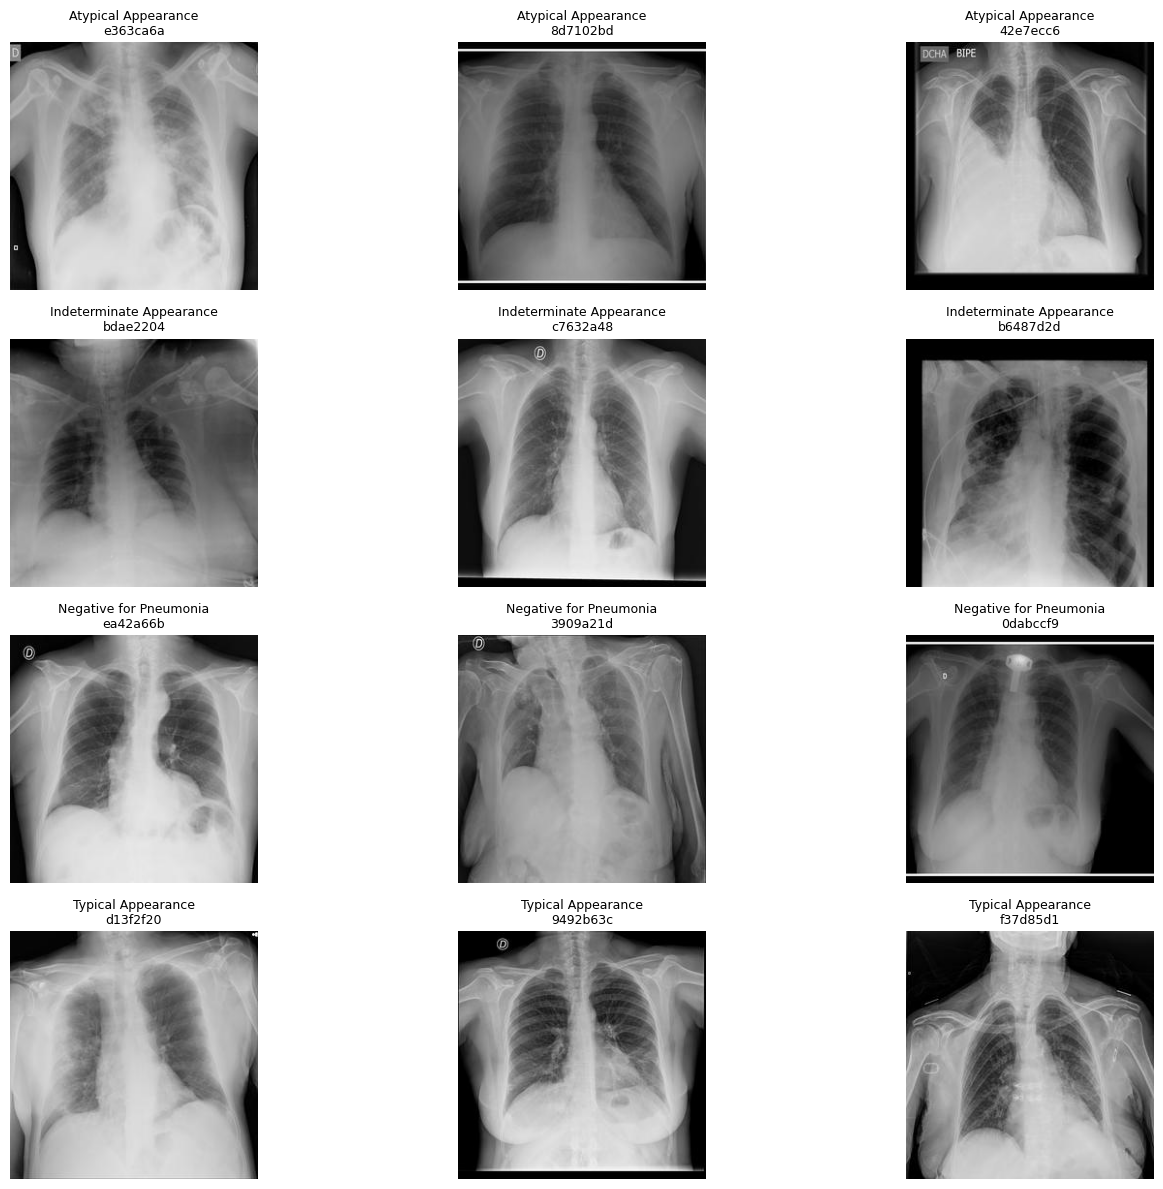

In [9]:
# Visualize sample images from each class
import cv2

def display_sample_images(df, num_samples=4):
    """Display sample images from each class"""
    fig, axes = plt.subplots(len(df['label_id'].unique()), num_samples, 
                            figsize=(15, 3 * len(df['label_id'].unique())))
    
    if len(df['label_id'].unique()) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, label in enumerate(sorted(df['label_id'].unique())):
        label_samples = df[df['label_id'] == label].sample(min(num_samples, len(df[df['label_id'] == label])))
        
        for col, (_, row) in enumerate(label_samples.iterrows()):
            img_path = row['image_path']
            if img_path and os.path.exists(str(img_path)):
                img = cv2.imread(str(img_path))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[idx, col].imshow(img)
                axes[idx, col].set_title(f"{label}\n{row['ImageInstanceUID'][:8]}", fontsize=9)
                axes[idx, col].axis('off')
            else:
                axes[idx, col].text(0.5, 0.5, 'Image not found', ha='center', va='center')
                axes[idx, col].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample images from training set:")
display_sample_images(train_split_df, num_samples=3)


In [10]:
# Save prepared data splits
train_split_df.to_csv(DATA_DIR / 'train_split.csv', index=False)
val_split_df.to_csv(DATA_DIR / 'val_split.csv', index=False)

print("Saved data splits:")
print(f"  - {DATA_DIR / 'train_split.csv'}")
print(f"  - {DATA_DIR / 'val_split.csv'}")

# Create a summary
summary = {
    'total_images': len(train_df),
    'train_images': len(train_split_df),
    'val_images': len(val_split_df),
    'classes': train_df['label_id'].unique().tolist(),
    'class_distribution': train_df['label_id'].value_counts().to_dict()
}

print("\nData Preparation Summary:")
print(f"  Total images: {summary['total_images']}")
print(f"  Training images: {summary['train_images']}")
print(f"  Validation images: {summary['val_images']}")
print(f"  Classes: {summary['classes']}")
print("\nData preparation complete! Ready for model training.")


Saved data splits:
  - data/train_split.csv
  - data/val_split.csv

Data Preparation Summary:
  Total images: 6334
  Training images: 5067
  Validation images: 1267
  Classes: ['Typical Appearance', 'Negative for Pneumonia', 'Atypical Appearance', 'Indeterminate Appearance']

Data preparation complete! Ready for model training.


In [11]:
train_split_df.head()

,ImageInstanceUID,StudyInstanceUID,label_id,study_label,height,width,boxes,image_label,image_path,image_exists
0,000a312787f2,5776db0cec75,Typical Appearance,1,3488,4256,"[{'x': 789.28836, 'y': 582.43035, 'width': 102...",opacity 1 789.28836 582.43035 1815.94498 2499....,data/256px/train/train/5776db0cec75_81456c9c54...,True
1,000c3a3f293f,ff0879eb20ed,Negative for Pneumonia,0,2320,2832,"[{'x': 0, 'y': 0, 'width': 1, 'height': 1}]",none 1 0 0 1 1,data/256px/train/train/ff0879eb20ed_d8a644cc4f...,True
3,001398f4ff4f,28dddc8559b2,Atypical Appearance,3,3520,4280,"[{'x': 2729, 'y': 2181.33331, 'width': 948.000...",opacity 1 2729 2181.33331 3677.00012 2785.33331,data/256px/train/train/28dddc8559b2_4d47bc042e...,True
4,001bd15d1891,dfd9fdd85a3e,Typical Appearance,1,2800,3408,"[{'x': 623.23328, 'y': 1050, 'width': 714, 'he...",opacity 1 623.23328 1050 1337.23328 2156 opaci...,data/256px/train/train/dfd9fdd85a3e_49170afa4f...,True
5,0022227f5adf,84543edc24c2,Indeterminate Appearance,2,2539,3050,"[{'x': 1857.2065, 'y': 508.30565, 'width': 376...",opacity 1 1857.2065 508.30565 2233.23384 907.8...,data/256px/train/train/84543edc24c2_82f65ab98e...,True
